In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import contextily as ctx
import geopandas as gpd
import zipfile
import os
import matplotlib.patches as mpatches
from shapely.geometry import Point
from matplotlib.lines import Line2D
import numpy as np

In [2]:
df_gare = pd.read_csv('gares-de-voyageurs.csv', sep=';')
df_aeroport = pd.read_csv('fr-airports.csv')
df_festival = pd.read_csv('festivals-global-festivals-pl.csv', sep=';')
df_tourisme = pd.read_csv('datatourisme-tour.csv')

culture_dtypes = {
    "Code Postal": "string",
    "Archéologie détail": "string",
    "Fonction_3": "string",
    "Fonction_4": "string",
    "Multiplexe": "string",
    "Jauge_du_theatre": "string",
    "Nom_de_l'Illustre": "string",
    "Annee_Label_Appellation": "string",
}

df_culture = pd.read_csv(
    'base-des-lieux-et-des-equipements-culturels.csv',
    sep=';',
    low_memory=False,
    dtype=culture_dtypes,
)


In [3]:
df_gare.head(2)

,Nom,Trigramme,Segment(s) DRG,Position géographique,Code commune,Code(s) UIC,id
0,Abancourt,ABT,C,"49.6852237, 1.7743058",60001,87313759,a99c4503-7fa0-4176-b908-74f5e50cba32
1,Abbaretz,AAR,C,"47.5546432, -1.5244159",44001,87481614,5fe4e77c-2519-413d-a242-4a525e656a09


In [4]:
df_gare.info()

<class 'pandas.DataFrame'>
RangeIndex: 2782 entries, 0 to 2781
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Nom                    2782 non-null   str  
 1   Trigramme              2782 non-null   str  
 2   Segment(s) DRG         2782 non-null   str  
 3   Position géographique  2782 non-null   str  
 4   Code commune           2782 non-null   int64
 5   Code(s) UIC            2782 non-null   str  
 6   id                     2782 non-null   str  
dtypes: int64(1), str(6)
memory usage: 152.3 KB


In [5]:
df_gare.drop('id', inplace=True, axis=1)

In [6]:
coords = df_gare['Position géographique'].astype(str).str.split(',', n=1, expand=True)

df_gare['lat'] = pd.to_numeric(coords[0].str.strip(), errors='coerce')
df_gare['lon'] = pd.to_numeric(coords[1].str.strip(), errors='coerce')

df_gare.drop('Position géographique', inplace=True, axis=1)

In [7]:
df_gare.duplicated().sum()

np.int64(0)

In [8]:
df_gare.isna().sum()

Nom               0
Trigramme         0
Segment(s) DRG    0
Code commune      0
Code(s) UIC       0
lat               0
lon               0
dtype: int64

In [9]:
for c in df_gare.columns:
    if not pd.api.types.is_numeric_dtype(df_gare[c]):
        print(c)
        print(df_gare[c].nunique())

Nom
2782
Trigramme
2782
Segment(s) DRG
8
Code(s) UIC
2782


In [10]:
df_gare["Segment(s) DRG"].value_counts()

Segment(s) DRG
C        1568
B        1077
A         128
A;A         3
B;B         2
A;B         2
B;C         1
A;B;A       1
Name: count, dtype: int64

In [11]:
df_gare['Segment(s) DRG'] = (
    df_gare['Segment(s) DRG']
    .astype('string')
    .str.extract(r'([A-Za-z])', expand=False)
    .str.upper()
)

df_gare.rename(columns={'Segment(s) DRG': 'Segment'}, inplace=True)
df_gare['Segment'].value_counts(dropna=False)

Segment
C    1568
B    1080
A     134
Name: count, dtype: Int64

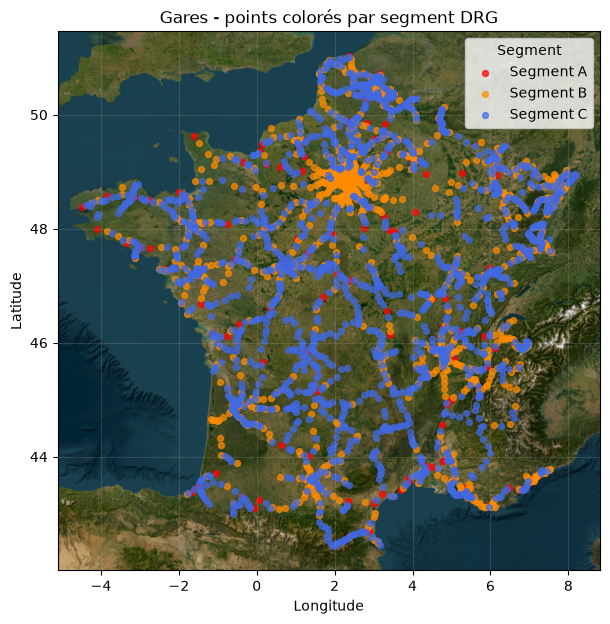

In [12]:
segment_colors = {
    'A': 'Red',
    'B': 'darkorange',
    'C': 'royalblue',
}

segment_col = 'Segment' if 'Segment' in df_gare.columns else 'Segment(s) DRG'
plot_gare = df_gare.dropna(subset=['lat', 'lon', segment_col]).copy()
plot_gare['segment_color'] = plot_gare[segment_col].map(segment_colors).fillna('gray')

fig, ax = plt.subplots(figsize=(7, 7))
for segment, color in segment_colors.items():
    subset = plot_gare[plot_gare[segment_col] == segment]
    ax.scatter(subset['lon'], subset['lat'], s=18, alpha=0.7, c=color, label=f'Segment {segment}')

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, crs="EPSG:4326", zoom_adjust=2, attribution=False)
ax.set_title('Gares - points colorés par segment DRG')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(alpha=0.2)
ax.legend(title='Segment')
plt.show()

In [13]:
df_aeroport.head(2)

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,4185,LFPG,large_airport,Charles de Gaulle International Airport,49.008960,2.554117,392.0,EU,France,FR,...,1,LFPG,LFPG,CDG,NaN,http://www.aeroportsdeparis.fr/,https://en.wikipedia.org/wiki/Charles_de_Gaull...,"PAR, Aéroport Roissy-Charles de Gaulle, Roissy...",1127475,2026-01-09T15:49:06+00:00
1,4189,LFPO,large_airport,Paris-Orly Airport,48.729499,2.358963,291.0,EU,France,FR,...,1,LFPO,LFPO,ORY,NaN,https://www.parisaeroport.fr/orly,https://en.wikipedia.org/wiki/Orly_Airport,NaN,1032775,2026-03-20T09:45:11+00:00


In [14]:
df_aeroport.info()

<class 'pandas.DataFrame'>
RangeIndex: 1756 entries, 0 to 1755
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1756 non-null   int64  
 1   ident              1756 non-null   str    
 2   type               1756 non-null   str    
 3   name               1756 non-null   str    
 4   latitude_deg       1756 non-null   float64
 5   longitude_deg      1756 non-null   float64
 6   elevation_ft       1595 non-null   float64
 7   continent          1756 non-null   str    
 8   country_name       1756 non-null   str    
 9   iso_country        1756 non-null   str    
 10  region_name        1756 non-null   str    
 11  iso_region         1756 non-null   str    
 12  local_region       1756 non-null   str    
 13  municipality       1229 non-null   str    
 14  scheduled_service  1756 non-null   int64  
 15  gps_code           437 non-null    str    
 16  icao_code          165 non-null    

In [15]:
df_aeroport.drop('gps_code', inplace=True, axis=1)
df_aeroport.drop('icao_code', inplace=True, axis=1)
df_aeroport.drop('iata_code', inplace=True, axis=1)
df_aeroport.drop('local_code', inplace=True, axis=1)
df_aeroport.drop('home_link', inplace=True, axis=1)
df_aeroport.drop('wikipedia_link', inplace=True, axis=1)
df_aeroport.drop('keywords', inplace=True, axis=1)
df_aeroport.drop('id', inplace=True, axis=1)


df_aeroport.info()

<class 'pandas.DataFrame'>
RangeIndex: 1756 entries, 0 to 1755
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ident              1756 non-null   str    
 1   type               1756 non-null   str    
 2   name               1756 non-null   str    
 3   latitude_deg       1756 non-null   float64
 4   longitude_deg      1756 non-null   float64
 5   elevation_ft       1595 non-null   float64
 6   continent          1756 non-null   str    
 7   country_name       1756 non-null   str    
 8   iso_country        1756 non-null   str    
 9   region_name        1756 non-null   str    
 10  iso_region         1756 non-null   str    
 11  local_region       1756 non-null   str    
 12  municipality       1229 non-null   str    
 13  scheduled_service  1756 non-null   int64  
 14  score              1756 non-null   int64  
 15  last_updated       1756 non-null   str    
dtypes: float64(3), int64(2), str(11)
me

In [16]:
df_aeroport.duplicated().sum()


np.int64(0)

In [17]:
print(df_aeroport["type"].value_counts())

type
small_airport     1057
heliport           435
medium_airport     118
closed             109
seaplane_base       19
large_airport       17
balloonport          1
Name: count, dtype: int64


In [18]:
print(df_aeroport["scheduled_service"].value_counts())

scheduled_service
0    1696
1      60
Name: count, dtype: int64


In [19]:
df_aeroport_commercial = df_aeroport[df_aeroport["scheduled_service"] == 1].copy()
df_aeroport_commercial.drop('last_updated', inplace=True, axis=1)
df_aeroport_commercial.drop('scheduled_service', inplace=True, axis=1)


df_aeroport_commercial.head(2)

,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,region_name,iso_region,local_region,municipality,score
0,LFPG,large_airport,Charles de Gaulle International Airport,49.008960,2.554117,392.0,EU,France,FR,Île-de-France,FR-IDF,IDF,"Paris (Roissy-en-France, Val-d'Oise)",1127475
1,LFPO,large_airport,Paris-Orly Airport,48.729499,2.358963,291.0,EU,France,FR,Île-de-France,FR-IDF,IDF,"Paris (Orly, Val-de-Marne)",1032775


In [20]:
print(df_aeroport_commercial["type"].value_counts())

type
medium_airport    35
large_airport     17
small_airport      6
heliport           2
Name: count, dtype: int64


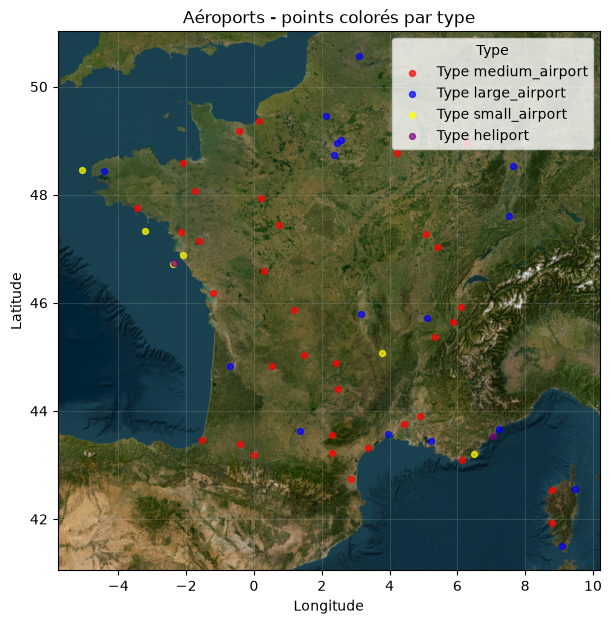

In [21]:
type_colors = {
    'medium_airport': 'red',
    'large_airport': 'blue',
    'small_airport': 'yellow',
    'heliport': 'purple'
}

type_col = 'type' 
plot_aeroport = df_aeroport_commercial.dropna(subset=['latitude_deg', 'longitude_deg', type_col]).copy()
plot_aeroport['type_color'] = plot_aeroport[type_col].map(type_colors).fillna('gray')

fig, ax = plt.subplots(figsize=(7, 7))
for type, color in type_colors.items():
    subset = plot_aeroport[plot_aeroport[type_col] == type]
    ax.scatter(subset['longitude_deg'], subset['latitude_deg'], s=18, alpha=0.7, c=color, label=f'Type {type}')

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, crs="EPSG:4326", zoom_adjust=2, attribution=False)
ax.set_title('Aéroports - points colorés par type')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(alpha=0.2)
ax.legend(title='Type')
plt.show()

In [22]:
print(df_aeroport["type"].value_counts())

type
small_airport     1057
heliport           435
medium_airport     118
closed             109
seaplane_base       19
large_airport       17
balloonport          1
Name: count, dtype: int64


 - shapefiles\BORNAGE_TOUT.shp
 - shapefiles\VSMAP_TOUT.shp


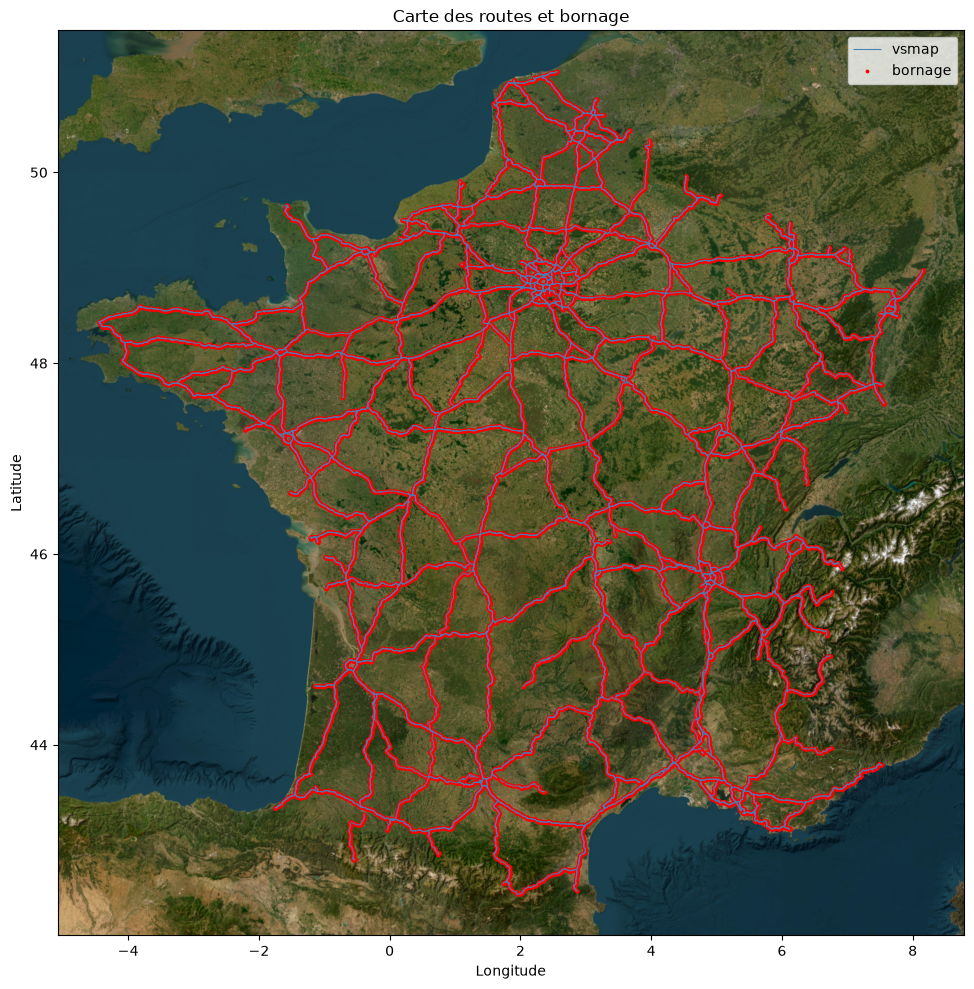

In [23]:
zip_path = "rrn-2025-metropole-shp.zip"
extract_dir = "shapefiles"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)


shps = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        if f.endswith(".shp"):
            shps.append(os.path.join(root, f))

for s in shps:
    print(" -", s)

bornage = gpd.read_file(shps[0])  
vsmap   = gpd.read_file(shps[1])  

if bornage.crs and bornage.crs.to_epsg() != 4326:
    bornage = bornage.to_crs(epsg=4326)
if vsmap.crs and vsmap.crs.to_epsg() != 4326:
    vsmap = vsmap.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(14, 10))

vsmap.plot(ax=ax, color="steelblue", linewidth=0.8, label="vsmap")
bornage.plot(ax=ax, color="red", markersize=3, label="bornage")

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, crs="EPSG:4326", zoom_adjust=2, attribution=False)
ax.legend()
ax.set_title("Carte des routes et bornage")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [24]:
df_gare_fr = df_gare.dropna(subset=['lat', 'lon']).copy()
df_gare_fr['lat'] = pd.to_numeric(df_gare_fr['lat'], errors='coerce')
df_gare_fr['lon'] = pd.to_numeric(df_gare_fr['lon'], errors='coerce')
df_gare_fr['dep'] = df_gare_fr['Code commune'].astype(str).str[:2]

gdf_gare = gpd.GeoDataFrame(
    df_gare_fr,
    geometry=gpd.points_from_xy(df_gare_fr['lon'], df_gare_fr['lat']),
    crs="EPSG:4326"
)

df_aero_fr = df_aeroport_commercial[df_aeroport_commercial['iso_country'] == 'FR'].copy()
df_aero_fr['latitude_deg']  = pd.to_numeric(df_aero_fr['latitude_deg'],  errors='coerce')
df_aero_fr['longitude_deg'] = pd.to_numeric(df_aero_fr['longitude_deg'], errors='coerce')
df_aero_fr = df_aero_fr[
    df_aero_fr['latitude_deg'].between(41, 52) &
    df_aero_fr['longitude_deg'].between(-5, 10)
].dropna(subset=['latitude_deg', 'longitude_deg'])

gdf_aero = gpd.GeoDataFrame(
    df_aero_fr,
    geometry=gpd.points_from_xy(df_aero_fr['longitude_deg'], df_aero_fr['latitude_deg']),
    crs="EPSG:4326"
)

df_festival = df_festival.rename(columns={'\ufeffNom du festival': 'Nom du festival'})
df_fest = df_festival.dropna(subset=['Géocodage xy']).copy()
df_fest[['lat_fest', 'lon_fest']] = df_fest['Géocodage xy'].str.split(',', expand=True).astype(float)

gdf_fest = gpd.GeoDataFrame(
    df_fest,
    geometry=gpd.points_from_xy(df_fest['lon_fest'], df_fest['lat_fest']),
    crs="EPSG:4326"
)

df_tour = df_tourisme.dropna(subset=['Latitude', 'Longitude']).copy()
df_tour['Latitude']  = pd.to_numeric(df_tour['Latitude'],  errors='coerce')
df_tour['Longitude'] = pd.to_numeric(df_tour['Longitude'], errors='coerce')
df_tour = df_tour[
    df_tour['Latitude'].between(41, 52) &
    df_tour['Longitude'].between(-5, 10)
]

df_cult = df_culture.dropna(subset=['Latitude', 'Longitude']).copy()
df_cult['Latitude']  = pd.to_numeric(df_cult['Latitude'],  errors='coerce')
df_cult['Longitude'] = pd.to_numeric(df_cult['Longitude'], errors='coerce')

url_dep = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
gdf_dep = gpd.read_file(url_dep)
gdf_dep['code'] = gdf_dep['code'].astype(str).str.zfill(2)

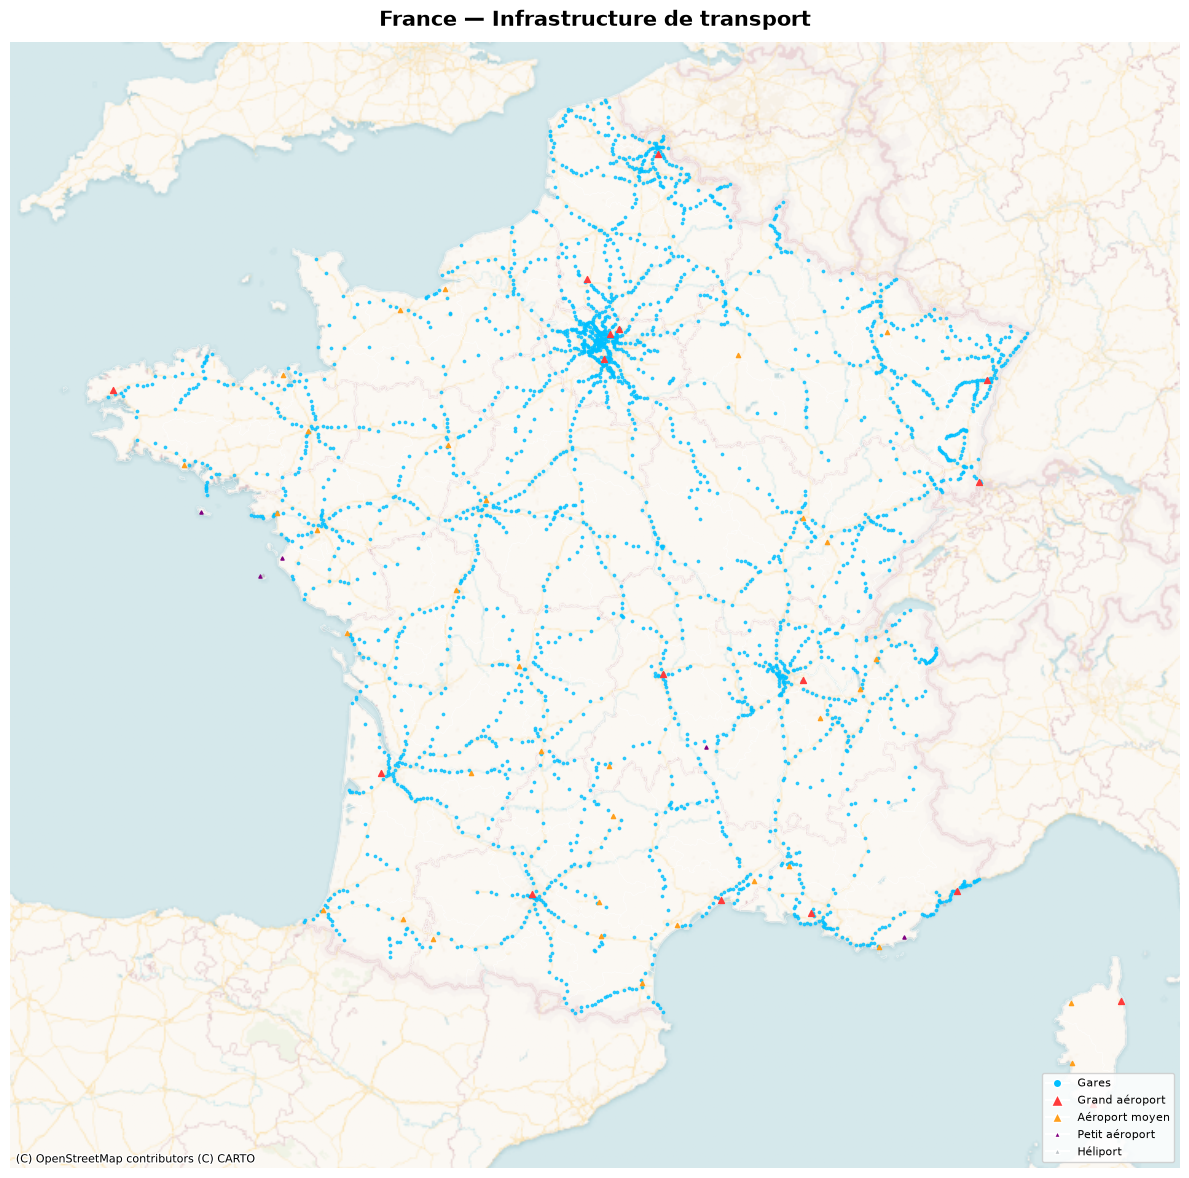

In [25]:
fig, ax = plt.subplots(figsize=(12, 13))

gdf_dep_wm   = gdf_dep.to_crs(epsg=3857)
gdf_gare_wm  = gdf_gare.to_crs(epsg=3857)
gdf_aero_wm  = gdf_aero.to_crs(epsg=3857)

gdf_dep_wm.plot(ax=ax, color="none", edgecolor="white", linewidth=0.4, alpha=0.6)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=6)

# Gares
gdf_gare_wm.plot(ax=ax, color="#00BFFF", markersize=3, alpha=0.75, zorder=3)

# Aéroports — palette bien distincte
AERO_STYLE = {
    "large_airport":  ("#FF3B3B", 18),
    "medium_airport": ("#FF9F1C",  9),
    "small_airport":  ("purple",  5),
    "heliport":       ("#BDC3C7",  3),
}
for atype, (color, size) in AERO_STYLE.items():
    sub = gdf_aero_wm[gdf_aero_wm["type"] == atype]
    if not sub.empty:
        sub.plot(ax=ax, color=color, markersize=size, marker="^", zorder=4)

# Légende manuelle
legend_items = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#00BFFF", markersize=6,  label="Gares"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#FF3B3B", markersize=9,  label="Grand aéroport"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#FF9F1C", markersize=7,  label="Aéroport moyen"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="purple", markersize=5,  label="Petit aéroport"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#BDC3C7", markersize=4,  label="Héliport"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=8,
          framealpha=0.85, edgecolor="#ccc")

ax.set_title("France — Infrastructure de transport", fontsize=15, fontweight="bold", pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("carte_transport.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Gares par département
gares_par_dep = df_gare_fr.groupby('dep').size().reset_index(name='nb_gares')
gdf_dep2 = gdf_dep.merge(gares_par_dep, left_on='code', right_on='dep', how='left')
gdf_dep2['nb_gares'] = gdf_dep2['nb_gares'].fillna(0)

# Créer GeoDataFrame avec TOUS les aéroports (pas juste commerciaux)
df_aero_all = df_aeroport[df_aeroport['iso_country'] == 'FR'].copy()
df_aero_all['latitude_deg']  = pd.to_numeric(df_aero_all['latitude_deg'],  errors='coerce')
df_aero_all['longitude_deg'] = pd.to_numeric(df_aero_all['longitude_deg'], errors='coerce')
df_aero_all = df_aero_all[
    df_aero_all['latitude_deg'].between(41, 52) &
    df_aero_all['longitude_deg'].between(-5, 10)
].dropna(subset=['latitude_deg', 'longitude_deg'])

gdf_aero_all = gpd.GeoDataFrame(
    df_aero_all,
    geometry=gpd.points_from_xy(df_aero_all['longitude_deg'], df_aero_all['latitude_deg']),
    crs="EPSG:4326"
)

# Aéroports par département (spatial join)
joined_aero = gpd.sjoin(gdf_aero_all, gdf_dep[['code', 'geometry']], how='left', predicate='within')
aero_par_dep = joined_aero.groupby('code').size().reset_index(name='nb_aero')
gdf_dep2 = gdf_dep2.merge(aero_par_dep, on='code', how='left')
gdf_dep2['nb_aero'] = gdf_dep2['nb_aero'].fillna(0)

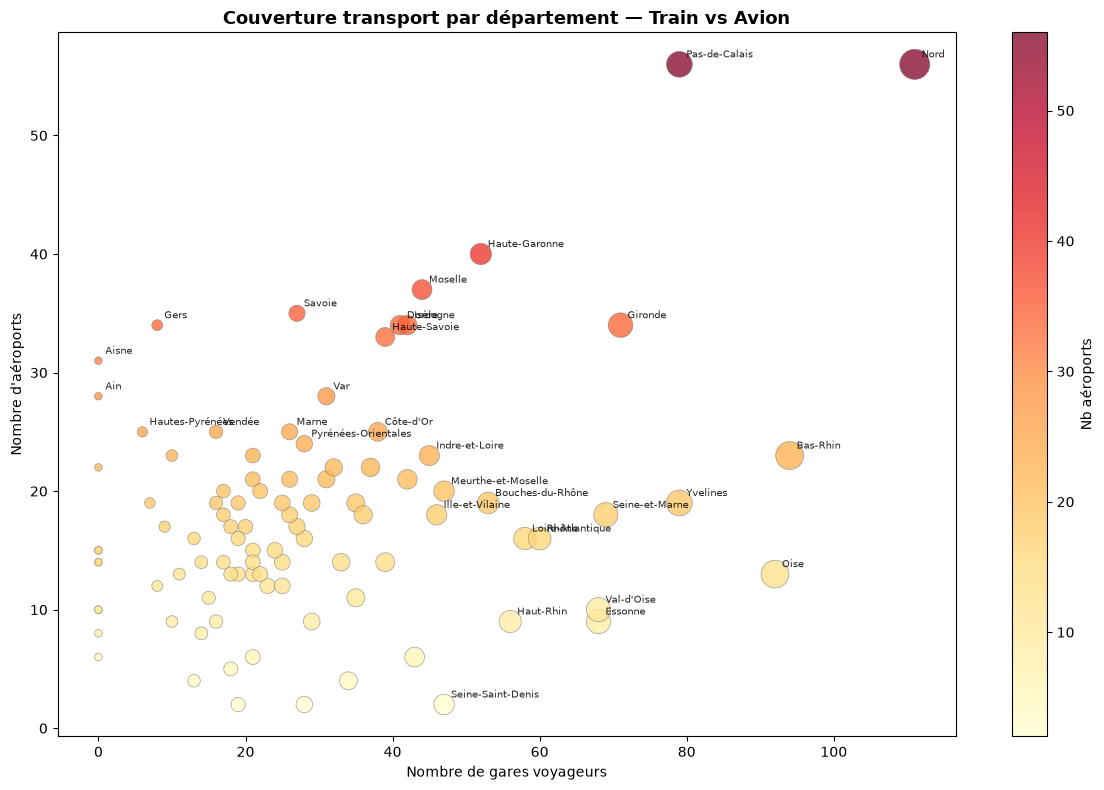

In [27]:
scatter_df = gdf_dep2[['code', 'nom', 'nb_gares', 'nb_aero']].dropna()

fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    scatter_df['nb_gares'],
    scatter_df['nb_aero'],
    s=scatter_df['nb_gares'] * 4 + 30,
    c=scatter_df['nb_aero'],
    cmap='YlOrRd', alpha=0.75, edgecolors='grey', linewidth=0.5
)

seuil_g = scatter_df['nb_gares'].quantile(0.80)
seuil_a = scatter_df['nb_aero'].quantile(0.80)
for _, row in scatter_df[
    (scatter_df['nb_gares'] > seuil_g) |
    (scatter_df['nb_aero']  > seuil_a)
].iterrows():
    ax.annotate(row['nom'], (row['nb_gares'], row['nb_aero']),
                fontsize=7, alpha=0.85,
                xytext=(5, 5), textcoords='offset points')

plt.colorbar(sc, ax=ax, label="Nb aéroports")
ax.set_xlabel("Nombre de gares voyageurs")
ax.set_ylabel("Nombre d'aéroports")
ax.set_title("Couverture transport par département — Train vs Avion",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("scatter_transport.png", dpi=150, bbox_inches='tight')
plt.show()

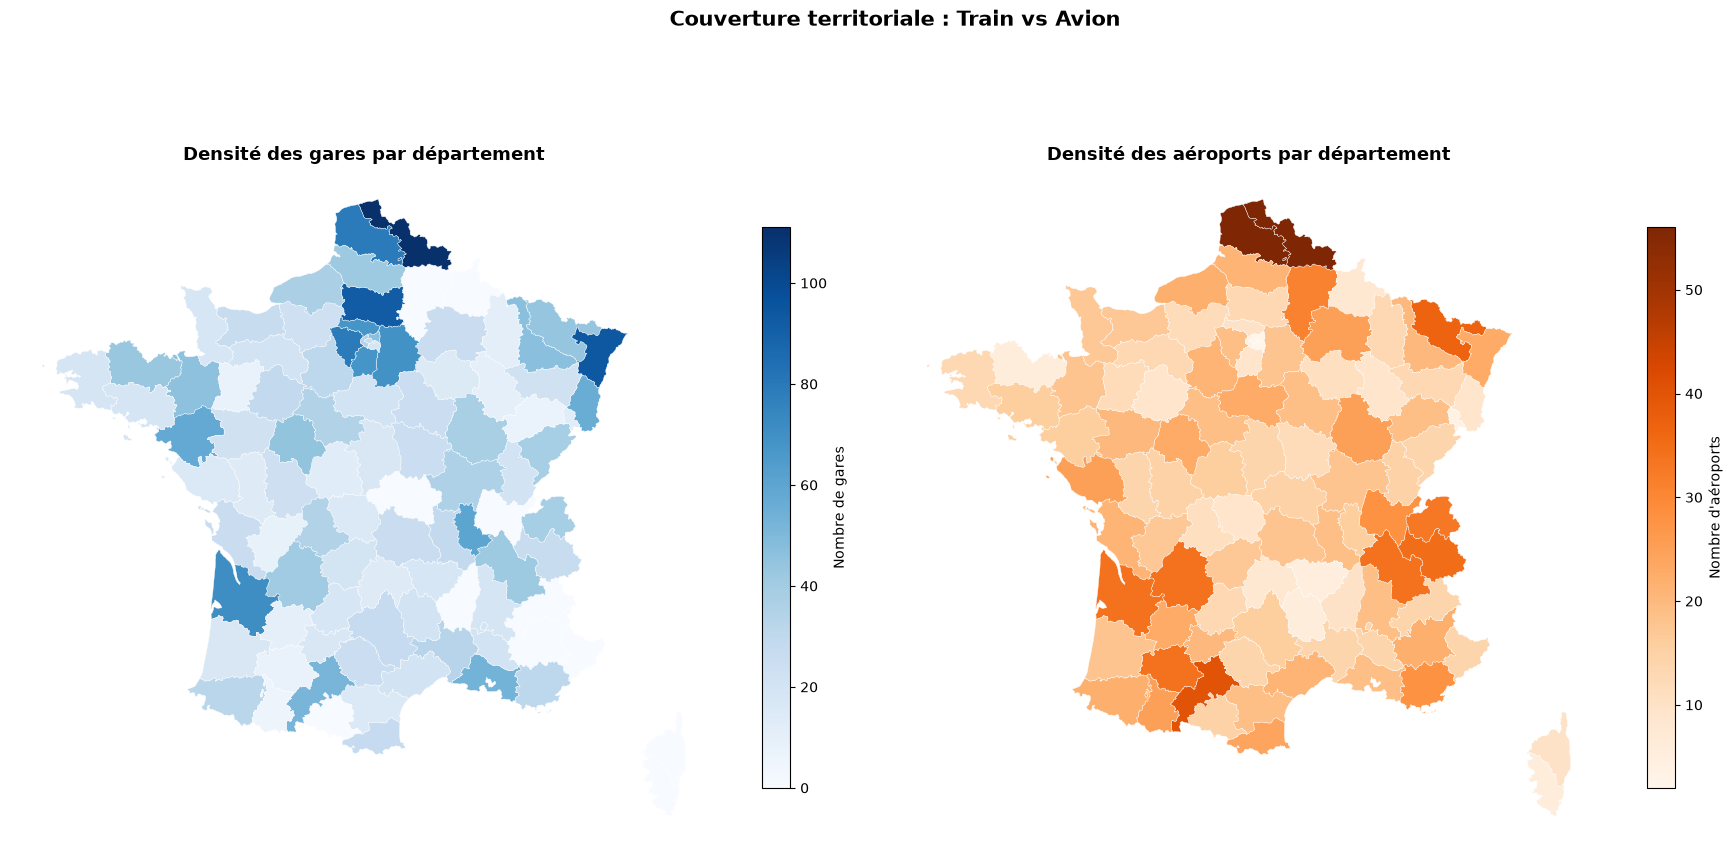

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

gdf_dep2.plot(column='nb_gares', ax=axes[0], cmap='Blues',
              legend=True, edgecolor='white', linewidth=0.3,
              legend_kwds={'label': "Nombre de gares", 'shrink': 0.6})
axes[0].set_title("Densité des gares par département", fontsize=13, fontweight='bold')
axes[0].axis('off')

gdf_dep2.plot(column='nb_aero', ax=axes[1], cmap='Oranges',
              legend=True, edgecolor='white', linewidth=0.3,
              legend_kwds={'label': "Nombre d'aéroports", 'shrink': 0.6})
axes[1].set_title("Densité des aéroports par département", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Couverture territoriale : Train vs Avion", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("densite_transport.png", dpi=150, bbox_inches='tight')
plt.show()

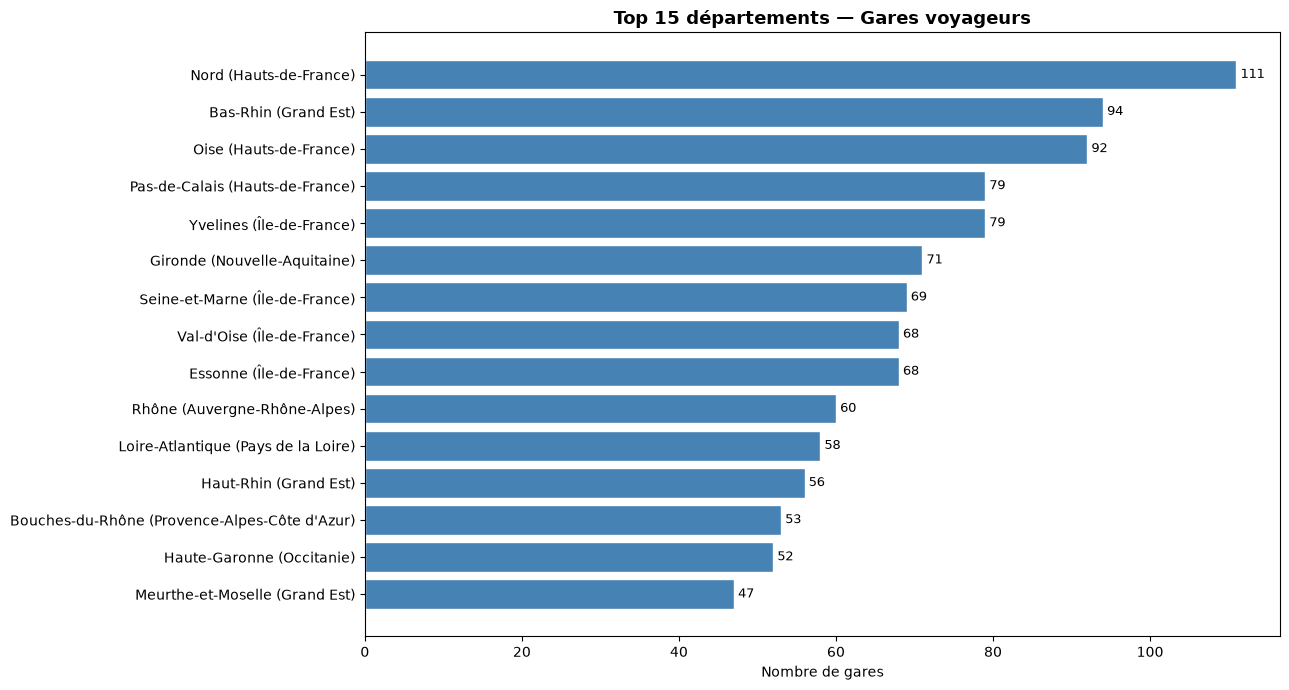

In [29]:
# On construit un mapping dep -> région depuis df_culture qui a Département + Région
mapping_dep_region = (
    df_culture[['N_Département', 'Département', 'Région']]
    .dropna(subset=['N_Département', 'Département', 'Région'])
    .drop_duplicates(subset=['N_Département'])
    .assign(dep=lambda x: x['N_Département'].astype(str).str.zfill(2))
    [['dep', 'Département', 'Région']]
)

# Fusionner avec gares_par_dep
top_gares = (
    gares_par_dep
    .sort_values('nb_gares', ascending=False)
    .head(15)
    .merge(mapping_dep_region, on='dep', how='left')
)

# Construire le label "Nom département (Région)"
top_gares['label'] = (
    top_gares['Département'].fillna(top_gares['dep'])
    + " ("
    + top_gares['Région'].fillna('?')
    + ")"
)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_gares['label'], top_gares['nb_gares'],
               color='steelblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Nombre de gares")
ax.set_title("Top 15 départements — Gares voyageurs", fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("top_gares.png", dpi=150, bbox_inches='tight')
plt.show()

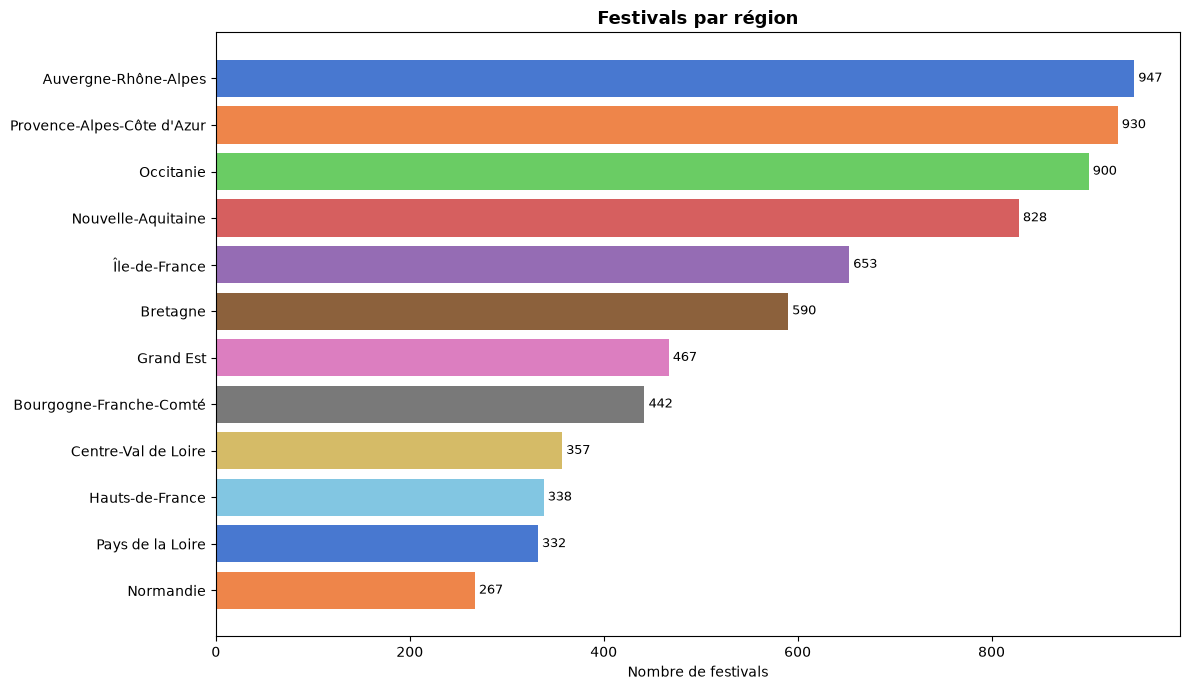

In [30]:
fig, ax = plt.subplots(figsize=(12, 7))

reg = df_fest['Région principale de déroulement'].value_counts().head(12)
bars_fest = ax.barh(reg.index, reg.values,
                    color=sns.color_palette("muted", len(reg)))
ax.bar_label(bars_fest, padding=3, fontsize=9)
ax.set_title("Festivals par région", fontsize=13, fontweight='bold')
ax.set_xlabel("Nombre de festivals")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("festivals_regions.png", dpi=150, bbox_inches='tight')
plt.show()

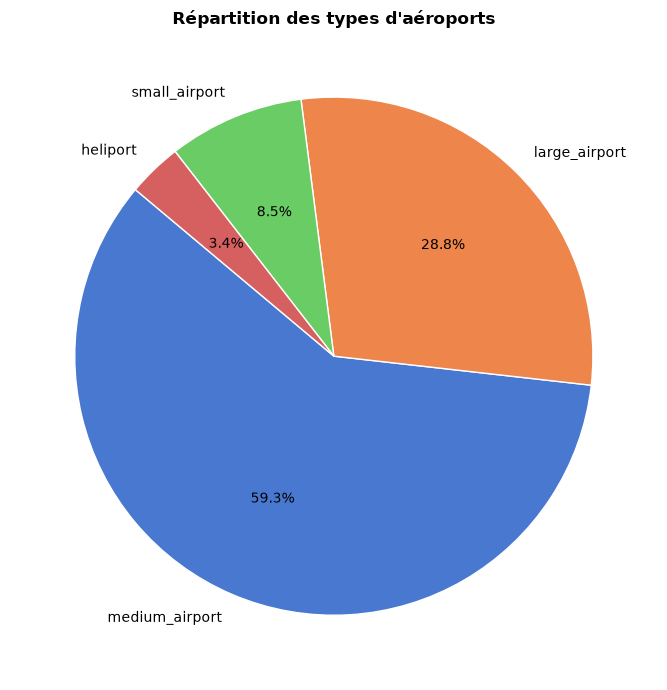

In [31]:
type_counts = df_aero_fr['type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette("muted", len(type_counts)),
       startangle=140, wedgeprops=dict(edgecolor='white'))
ax.set_title("Répartition des types d'aéroports", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("repartition_aeroports.png", dpi=150, bbox_inches='tight')
plt.show()

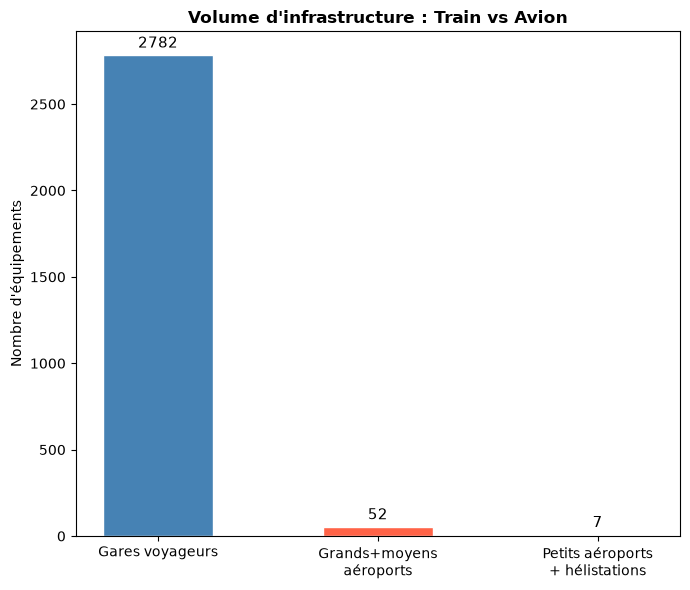

In [32]:
categories = ['Gares voyageurs', 'Grands+moyens\naéroports', 'Petits aéroports\n+ hélistations']
values = [
    len(df_gare_fr),
    len(df_aero_fr[df_aero_fr['type'].isin(['large_airport', 'medium_airport'])]),
    len(df_aero_fr[df_aero_fr['type'].isin(['small_airport', 'heliport'])]),
]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(categories, values, color=['steelblue', 'tomato', 'gold'],
              edgecolor='white', width=0.5)
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_title("Volume d'infrastructure : Train vs Avion", fontsize=12, fontweight='bold')
ax.set_ylabel("Nombre d'équipements")
plt.tight_layout()
plt.savefig("volume_infrastructure.png", dpi=150, bbox_inches='tight')
plt.show()